This is the file for using logit lens to extract a model's intermediate layers, compare each of the layer with the final layer sematically is our main feature. BERTScore(i, final), i=1 to (numLayers-1)

In [1]:
#Required libraries
!pip install transformers accelerate huggingface-hub bert-score
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 84.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [5]:
# Load libraries and login
from huggingface_hub import login
from google.colab import userdata
from bert_score import score
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt

login(token=userdata.get('gc'))

In [6]:
model_id = "meta-llama/Meta-Llama-3-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        device_map="auto"
    )
model.eval()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [7]:
def calculate_bertscore(cands, ref):
    refs = [ref] * len(cands)
    P, R, F1 = score(cands, refs, lang="en", verbose=True)
    return P, R, F1


def extract_features(tokenizer, model, prompt, max_new_tokens=100):

    # format the input
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)

    # save length of prompt for later calcs
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            output_hidden_states=True,
            output_scores=True,
            return_dict_in_generate=True
        )

    sequences = generated_output.sequences
    hidden_states = generated_output.hidden_states  # (gen_steps, layers, batch, seq_len_t, dim)
    scores = generated_output.scores                # (gen_steps, batch, vocab)
    generated_tokens = sequences[0, prompt_len:]   # (gen_len,)

    # final reference text
    final_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)


    lm_head = model.lm_head
    norm = model.model.norm

    # intermediate layer tokens
    layer_texts_per_token = []
    for step_hidden in hidden_states:
        step_layer_tokens = []
        for layer_h in step_hidden[1:-1]:           # skip embed and final layer
            logit = lm_head(norm(layer_h))          # (batch, 1, vocab)
            token = torch.argmax(logit, dim=-1)[0, -1]  # (1,)
            step_layer_tokens.append(token.item())
        layer_texts_per_token.append(step_layer_tokens)

    # decode intermediate layer texts
    num_layers = len(layer_texts_per_token[0])
    layer_texts = []
    for layer_idx in range(num_layers):
        token_ids = [layer_texts_per_token[step][layer_idx]
                     for step in range(len(hidden_states))]
        text = tokenizer.decode(token_ids, skip_special_tokens=True)
        layer_texts.append(text if text.strip() else "[EMPTY]")

    # BERT scores
    precision, recall, f1 = calculate_bertscore(layer_texts, final_text)

    # raw confidence (log confidence calc)
    token_probs = torch.stack([
        torch.softmax(s, dim=-1) for s in scores
    ], dim=1)  # (batch, gen_len, vocab)

    token_probs_generated = token_probs[0].gather(1, generated_tokens.unsqueeze(-1)).squeeze(-1)  # (gen_len,)

    # sanity check
    assert token_probs_generated.shape[0] == len(generated_tokens), \
        f"Shape mismatch: {token_probs_generated.shape[0]} vs {len(generated_tokens)}"

    log_confidence = torch.sum(torch.log(token_probs_generated + 1e-10)).item()

    # nomalized log confidence, use this
    norm_log_confidence = log_confidence / len(generated_tokens)

    return {
        "final_text": final_text,
        "layer_texts": layer_texts,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "log_confidence": log_confidence,
        "normalized_log_confidence": norm_log_confidence
    }

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 2.92 seconds, 10.63 sentences/sec
The remains of the RMS Titanic were discovered on September 1, 1985, by a French-American expedition led by Dr. Robert Ballard and Jean-Louis Michel. The team used a combination of sonar and submersible vehicles to locate and explore the wreckage, which was lying at a depth of about 12,500 feet (3,800 meters) in the North Atlantic Ocean.

The expedition was sponsored by the Woods Hole Oceanographic Institution, the National Geographic Society, and the French Institute


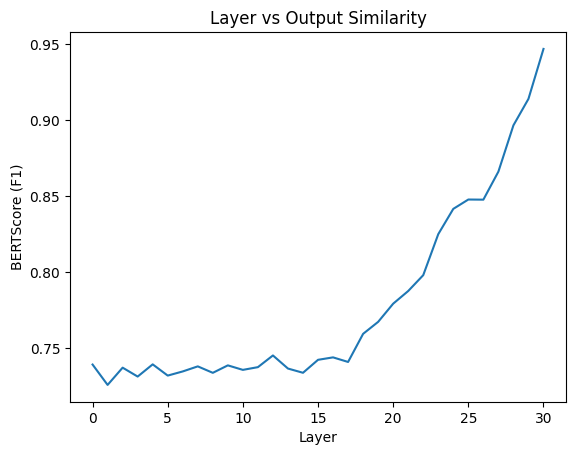

In [8]:

prompt = "Who found the remains of the Titanic?"
results = extract_features(tokenizer, model, prompt)

print(results["final_text"])

plt.plot(results["f1"].numpy())
plt.xlabel("Layer")
plt.ylabel("BERTScore (F1)")
plt.title("Layer vs Output Similarity")
plt.show()

# Replicating Classifiers from MICE Paper

In [9]:
import os
from google.colab import drive
from datasets import load_dataset, Dataset, load_from_disk
import uuid

drive.mount('/content/drive')

base_folder = r"CSCI 5980 8980 Project"
data_path = f"/content/drive/MyDrive/{base_folder}/Notebooks/Data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
combined = load_from_disk(os.path.join(data_path, "combined_datasets_hf"))

combined = combined.shuffle(seed=42).select(range(5))  # subsample (3k max)

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
X_list = []
y_list = []
results_full = []

for example in combined:
    prompt = example["question"]

    results = extract_features(tokenizer, model, prompt)
    f1 = results["f1"]
    norm_log = results["normalized_log_confidence"]
    final_text = results["final_text"]

    features = np.concatenate([
        f1,
        [norm_log]
    ])

    X_list.append(features)

    y = 1 if example["type"] == "answer" else 0
    y_list.append(y)

    results_full.append({
        "prompt": prompt,
        "final_text": final_text,
        "f1": f1,
        "norm_log": norm_log,
        "y": y
    })

X_all = np.array(X_list)
y_all = np.array(y_list)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.62 seconds, 49.63 sentences/sec


In [15]:
# print results_full
for result in results_full:
    print(result)


{'prompt': 'What caused the disappearance of the ancient civilization of the Indus Valley?', 'final_text': 'The Indus Valley Civilization, also known as the Harappan Civilization, was a Bronze Age civilization that flourished in the Indus Valley region of modern-day Pakistan and northwestern India from around 3300 to 1300 BCE. The civilization is known for its sophisticated urban planning, architecture, and water management systems, as well as its writing system and art.\n\nThe reasons for the decline and disappearance of the Indus Valley Civilization are still debated among historians and archaeologists. There are several theories', 'f1': tensor([0.7353, 0.7413, 0.7325, 0.7435, 0.7420, 0.7404, 0.7372, 0.7373, 0.7363,
        0.7344, 0.7429, 0.7381, 0.7468, 0.7371, 0.7424, 0.7499, 0.7378, 0.7502,
        0.7803, 0.7857, 0.7979, 0.8228, 0.8295, 0.8423, 0.8448, 0.8643, 0.8789,
        0.8942, 0.9117, 0.9258, 0.9615]), 'norm_log': -0.12794939041137696, 'y': 0}
{'prompt': 'Compose an in-de

In [ ]:
# train & test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# normalize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [ ]:
# start --- random forest & logistic regression replication


import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [ ]:
# RF
mice_rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    max_features=10,
    random_state=42,
    n_jobs=-1,
)
mice_rf.fit(X_train, y_train)

In [ ]:
# LR
mice_lr = LogisticRegression(
    C=0.5,
    max_iter=1000,
    random_state=42,
)
mice_lr.fit(X_train_s, y_train)

In [ ]:
# evals
p_hat_rf = mice_rf.predict_proba(X_test)[:, 1]
p_hat_lr = mice_lr.predict_proba(X_test_s)[:, 1]

print("RF  — mean: {:.3f}  |  true accuracy: {:.3f}".format(
    p_hat_rf.mean(), y_test.mean()))
print("LR  — mean: {:.3f}  |  true accuracy: {:.3f}".format(
    p_hat_lr.mean(), y_test.mean()))

In [ ]:
# calibration curve (smECE) - copied from web

def silverman_bandwidth(p_hat: np.ndarray) -> float:
    """Silverman's rule of thumb for 1-D kernel density."""
    n  = len(p_hat)
    std = np.std(p_hat, ddof=1)
    iqr = np.percentile(p_hat, 75) - np.percentile(p_hat, 25)
    s   = min(std, iqr / 1.34)
    return 0.9 * s * n**(-0.2)


def nw_accuracy(p_eval: float, p_hat: np.ndarray,
                y_true: np.ndarray, bw: float) -> float:
    """
    Nadaraya–Watson estimate of local accuracy at p_eval.
    Uses a reflected Gaussian kernel so boundary mass is
    preserved (matches the smECE paper's implementation).
    """
    # Reflected kernel: kernel(p, p_eval) + kernel(2-p, p_eval) + kernel(-p, p_eval)
    def gauss_k(u):
        return np.exp(-0.5 * (u / bw) ** 2)

    k  = gauss_k(p_hat - p_eval)
    k += gauss_k(p_hat + p_eval)        # reflection at 0
    k += gauss_k(p_hat - (2 - p_eval))  # reflection at 1

    denom = k.sum()
    if denom < 1e-12:
        return p_eval   # fall back to identity if no mass nearby
    return (k * y_true).sum() / denom


def compute_smece(p_hat: np.ndarray, y_true: np.ndarray,
                  n_eval: int = 500) -> float:
    """
    Smooth ECE via Nadaraya–Watson kernel regression.
    Evaluates at n_eval equally-spaced points in [0, 1] and
    weights each by the local density of predictions there,
    approximating E[ |acc(p̂) − p̂| ].
    """
    bw         = silverman_bandwidth(p_hat)
    eval_grid  = np.linspace(0, 1, n_eval)
    errors, weights = [], []

    for p_eval in eval_grid:
        acc_local = nw_accuracy(p_eval, p_hat, y_true.astype(float), bw)
        # local density weight (unnormalised) — same reflected kernel
        def gauss_k(u): return np.exp(-0.5 * (u / bw) ** 2)
        density = (gauss_k(p_hat - p_eval)
                   + gauss_k(p_hat + p_eval)
                   + gauss_k(p_hat - (2 - p_eval))).sum()
        errors.append(abs(acc_local - p_eval))
        weights.append(density)

    weights = np.array(weights)
    weights /= weights.sum()
    return float(np.dot(errors, weights))

In [ ]:
smece_rf = compute_smece(p_hat_rf, y_test)
smece_lr = compute_smece(p_hat_lr, y_test)
print(f"smECE — MICE RF : {smece_rf:.4f}")
print(f"smECE — MICE LR : {smece_lr:.4f}")